In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

In [2]:
data = load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [10]:
data.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [12]:
X = data.data
y = data.target

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [15]:
X_train.shape

(353, 10)

In [17]:
L  = LinearRegression()

In [18]:
L.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = L.predict(X_test)

In [20]:
from sklearn.metrics import r2_score, mean_squared_error

In [22]:
print("r2_score: ", r2_score(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

r2_score:  0.4588389962630465
RMSE:  56.31684134646978


In [23]:
from sklearn.linear_model import Ridge

In [24]:
R = Ridge(alpha=0.0001)

In [25]:
R.fit(X_train, y_train)

Ridge(alpha=0.0001)

In [26]:
y_pred1 = R.predict(X_test)

In [27]:
print("r2_score: ", r2_score(y_test, y_pred1))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred1)))

r2_score:  0.45903333452161754
RMSE:  56.30672836756193


In [28]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.rand(m, 1)

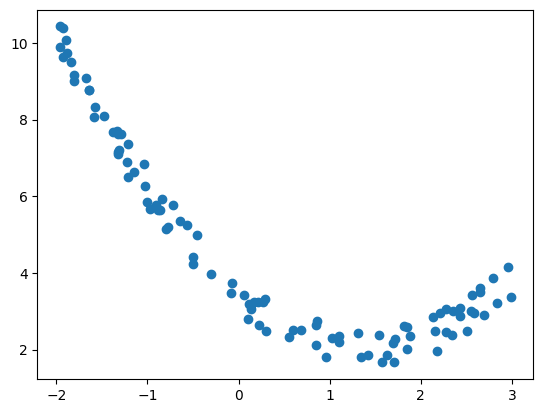

In [31]:
plt.scatter(x1, x2)
plt.show()

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [35]:
def get_pred_ridge(x1, x2, alpha):
    model = Pipeline([
       ("poly_features", PolynomialFeatures(degree=30)),
        ("Ridge", Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

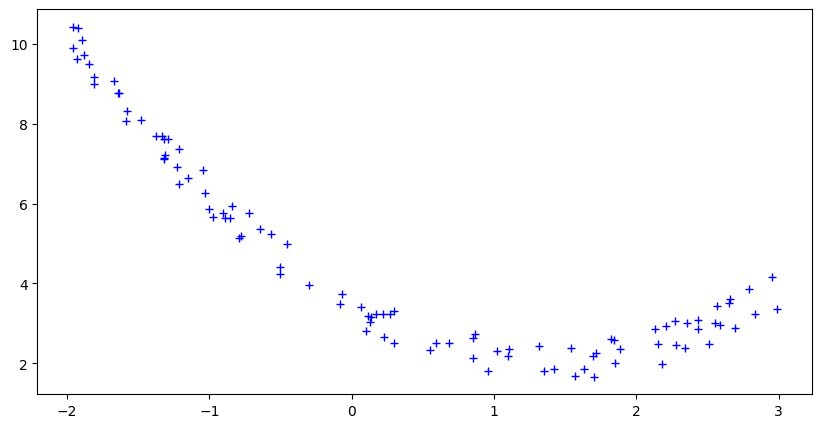

In [37]:
alphas = [0, 20, 200]
cs = ["r", "g", "b"]

plt.figure(figsize=(10,5))
plt.plot(x1, x2, "b+", label = "datapoints")

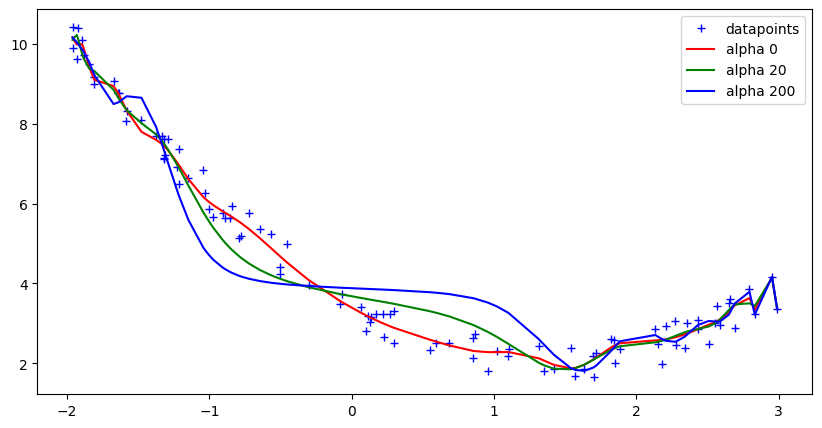

In [40]:
alphas = [0, 20, 200]
cs = ["r", "g", "b"]

plt.figure(figsize=(10,5))
plt.plot(x1, x2, "b+", label = "datapoints")

for alpha, c in zip(alphas, cs):
    preds = get_pred_ridge(x1, x2, alpha)
    
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c, label = "alpha {}".format(alpha))

plt.legend()
plt.show()